# DistilBERT: HPO, Final Evaluation and LIME

1. Loads and fine tunes pretrained DistilBERT model
2. Conducts hyperaparameter tuning
3. Conducts vocabulary analysis with word clouds and LIME interpretability.

In [1]:
# Run this only if needed:
# !pip install -q torch transformers datasets accelerate scikit-learn lime

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support, ConfusionMatrixDisplay
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

SPLITS_DIR = Path('splits')
OUTPUT_DIR = Path('distilbert_hpo')
RESULTS_FILE = OUTPUT_DIR / 'hpo_results.csv'
FINAL_DIR = OUTPUT_DIR / 'final_results'

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256
EPOCHS = 10
RANDOM_STATE = 42
RUN_HPO = True

LABELS = ['Negative', 'Neutral', 'Positive']
ID2LABEL = dict(enumerate(LABELS))
LABEL2ID = {label: index for index, label in ID2LABEL.items()}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EXPERIMENTS = [
    {'run': 'baseline',    'lr': 2e-5, 'batch_size': 16, 'dropout': 0.2},
    {'run': 'lr_1e-5',    'lr': 1e-5, 'batch_size': 16, 'dropout': 0.2},
    {'run': 'lr_3e-5',    'lr': 3e-5, 'batch_size': 16, 'dropout': 0.2},
    {'run': 'batch_32',   'lr': 2e-5, 'batch_size': 32, 'dropout': 0.2},
    {'run': 'dropout_0.1','lr': 2e-5, 'batch_size': 16, 'dropout': 0.1},
    {'run': 'dropout_0.3','lr': 2e-5, 'batch_size': 16, 'dropout': 0.3},
]

OUTPUT_DIR.mkdir(exist_ok=True)
set_seed(RANDOM_STATE)
print('Device:', DEVICE)
pd.DataFrame(EXPERIMENTS)


c:\Users\tsega\anaconda3\envs\midterm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


,run,lr,batch_size,dropout
0,baseline,0.00002,16,0.2
1,lr_1e-5,0.00001,16,0.2
2,lr_3e-5,0.00003,16,0.2
3,batch_32,0.00002,32,0.2
4,dropout_0.1,0.00002,16,0.1
5,dropout_0.3,0.00002,16,0.3


In [3]:
train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
val_df = pd.read_csv(SPLITS_DIR / 'val.csv')
test_df = pd.read_csv(SPLITS_DIR / 'test.csv')

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

def make_dataset(df):
    dataset = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return dataset.map(tokenize, batched=True, remove_columns=['text'])

tokenized_train = make_dataset(train_df)
tokenized_val = make_dataset(val_df)
tokenized_test = make_dataset(test_df)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Train: (143985, 4)
Validation: (15999, 4)
Test: (39996, 4)


Map: 100%|██████████| 39996/39996 [00:04<00:00, 9927.72 examples/s] 


In [4]:
def compute_metrics(prediction):
    logits, labels = prediction
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }


def build_model(dropout):
    config = AutoConfig.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        dropout=dropout,
        attention_dropout=dropout,
        seq_classif_dropout=dropout,
    )
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)


## Hyperparameter Tuning

This uses the validation set to select the best configuration. The test set is not used here.

In [5]:
if RUN_HPO:
    results = []

    for exp in EXPERIMENTS:
        print(f"Running {exp['run']}")
        model = build_model(exp['dropout'])

        args = TrainingArguments(
            output_dir=str(OUTPUT_DIR / exp['run']),
            learning_rate=exp['lr'],
            per_device_train_batch_size=exp['batch_size'],
            per_device_eval_batch_size=exp['batch_size'],
            num_train_epochs=EPOCHS,
            weight_decay=0.01,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            save_total_limit=1,
            report_to='none',
            fp16=torch.cuda.is_available(),
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        )

        trainer.train()
        metrics = trainer.evaluate()
        results.append({
            **exp,
            'val_accuracy': metrics['eval_accuracy'],
            'val_macro_f1': metrics['eval_f1_macro'],
            'checkpoint': trainer.state.best_model_checkpoint,
        })

    hpo_results = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
    hpo_results.to_csv(RESULTS_FILE, index=False)
else:
    hpo_results = pd.read_csv(RESULTS_FILE)

print('HPO results:')
display(hpo_results)


Running baseline


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1969.21it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.436484,0.427220,0.824677,0.822858,0.824677,0.823032
2,0.393867,0.409603,0.832490,0.833670,0.832490,0.832957
3,0.348842,0.438851,0.831302,0.833093,0.831302,0.831803
4,0.297214,0.481167,0.830177,0.829621,0.830177,0.829738


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.06it/s]


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.297214,0.409603,4,0.832490,0.833670,0.832490,0.832957


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.454560,0.432712,0.823114,0.824384,0.823114,0.823549
2,0.414581,0.427384,0.827114,0.828231,0.827114,0.827405
3,0.382861,0.440066,0.833365,0.833022,0.833365,0.833025
4,0.346249,0.451659,0.826802,0.825807,0.826802,0.826181
5,0.335574,0.497404,0.825239,0.823464,0.825239,0.823910


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.335574,0.440066,5,0.833365,0.833022,0.833365,0.833025


HPO results:


,run,lr,batch_size,dropout,val_accuracy,val_macro_f1,checkpoint
0,lr_1e-5,0.00001,16,0.2,0.834427,0.835067,distilbert_hpo\lr_1e-5\checkpoint-27000
1,batch_32,0.00002,32,0.2,0.833365,0.834185,distilbert_hpo\batch_32\checkpoint-13500
2,dropout_0.3,0.00002,16,0.3,0.833365,0.833025,distilbert_hpo\dropout_0.3\checkpoint-27000
3,baseline,0.00002,16,0.2,0.832490,0.832957,distilbert_hpo\baseline\checkpoint-18000
4,lr_3e-5,0.00003,16,0.2,0.831302,0.831842,distilbert_hpo\lr_3e-5\checkpoint-27000
5,dropout_0.1,0.00002,16,0.1,0.830177,0.830369,distilbert_hpo\dropout_0.1\checkpoint-18000


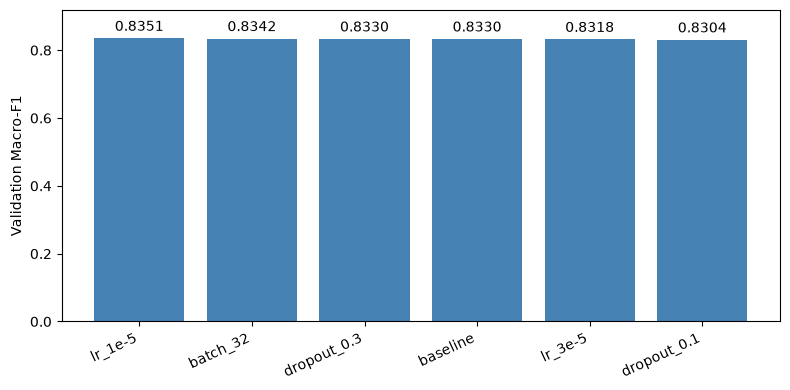

In [15]:
f1_column = 'val_macro_f1' if 'val_macro_f1' in hpo_results.columns else 'validation_f1_macro'
plt.figure(figsize=(8, 4))
bars = plt.bar(hpo_results['run'], hpo_results[f1_column], color='steelblue')
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.ylabel('Validation Macro-F1')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, hpo_results[f1_column].max() * 1.1)

plt.tight_layout()
plt.show()

## Final Model Evaluation

The best configuration is chosen by validation macro-F1 and evaluated once on the test set.

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2494.08it/s]


Selected run: lr_1e-5
              precision    recall  f1-score   support

    Negative     0.8421    0.8635    0.8527     13332
     Neutral     0.7410    0.7571    0.7490     13332
    Positive     0.9043    0.8617    0.8825     13332

    accuracy                         0.8274     39996
   macro avg     0.8291    0.8274    0.8280     39996
weighted avg     0.8291    0.8274    0.8280     39996



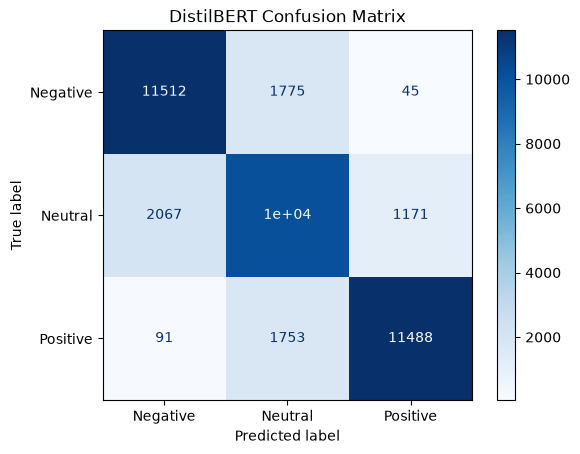

In [7]:
f1_column = 'val_macro_f1' if 'val_macro_f1' in hpo_results.columns else 'validation_f1_macro'
best_row = hpo_results.sort_values(f1_column, ascending=False).iloc[0]
checkpoint_column = 'checkpoint' if 'checkpoint' in hpo_results.columns else 'best_checkpoint'
best_checkpoint = Path(best_row[checkpoint_column])

final_model = AutoModelForSequenceClassification.from_pretrained(best_checkpoint)
final_args = TrainingArguments(
    output_dir=str(FINAL_DIR),
    per_device_eval_batch_size=int(best_row['batch_size']),
    report_to='none',
    fp16=torch.cuda.is_available(),
)
final_trainer = Trainer(
    model=final_model,
    args=final_args,
    processing_class=tokenizer,
    data_collator=data_collator,
)

output = final_trainer.predict(tokenized_test)
predictions = np.argmax(output.predictions, axis=1)
report = classification_report(test_df['label'], predictions, target_names=LABELS, digits=4)

print('Selected run:', best_row['run'])
print(report)

ConfusionMatrixDisplay.from_predictions(test_df['label'], predictions, display_labels=LABELS, cmap='Blues')
plt.title('DistilBERT Confusion Matrix')
plt.show()

FINAL_DIR.mkdir(parents=True, exist_ok=True)
results_df = test_df.copy()
results_df['prediction'] = predictions
results_df['true_sentiment'] = results_df['label'].map(ID2LABEL)
results_df['predicted_sentiment'] = results_df['prediction'].map(ID2LABEL)
results_df['is_correct'] = results_df['label'] == results_df['prediction']
results_df.to_csv(FINAL_DIR / 'test_predictions.csv', index=False)


## Vocabulary Analysis: Bag of Words and Word Cloud

This section shows the most frequent words in each labelled sentiment class. It uses a balanced sample from the training set, so it is descriptive and does not change the model. The Bag of Words chart shows exact word counts; the Word Cloud is only a visual summary. For model-specific explanations, use the LIME section below.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud

VOCAB_SAMPLE_PER_CLASS = 3000
TOP_WORDS = 15
VOCAB_DIR = FINAL_DIR / 'vocabulary'
VOCAB_DIR.mkdir(parents=True, exist_ok=True)

# Keep useful negation words because they can affect sentiment.
STOP_WORDS = set(ENGLISH_STOP_WORDS) - {'no', 'nor', 'not', 'never'}
COLORS = {'Negative': '#d95f02', 'Neutral': '#7570b3', 'Positive': '#1b9e77'}

print('Vocabulary output folder:', VOCAB_DIR)

Vocabulary output folder: distilbert_hpo\final_results\vocabulary


In [9]:
# Create a balanced sample from the training data.
vocab_sample = pd.concat([
    train_df[train_df['label'] == label].sample(
        n=min(VOCAB_SAMPLE_PER_CLASS, (train_df['label'] == label).sum()),
        random_state=RANDOM_STATE,
    )
    for label in range(3)
], ignore_index=True)

def top_words(texts, n=TOP_WORDS):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=list(STOP_WORDS),
        min_df=2,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
    )
    matrix = vectorizer.fit_transform(texts.fillna(''))
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    words = vectorizer.get_feature_names_out()
    result = pd.DataFrame({'word': words, 'count': counts})
    return result.sort_values('count', ascending=False).head(n).reset_index(drop=True)

top_word_tables = {}
for label, sentiment in enumerate(LABELS):
    texts = vocab_sample.loc[vocab_sample['label'] == label, 'text']
    top_word_tables[sentiment] = top_words(texts)

top_words_df = pd.concat(
    [table.assign(sentiment=sentiment) for sentiment, table in top_word_tables.items()],
    ignore_index=True,
)
top_words_df.to_csv(VOCAB_DIR / 'top_words_by_sentiment.csv', index=False)

display(top_words_df.pivot(index='word', columns='sentiment', values='count').fillna('').head(15))

sentiment,Negative,Neutral,Positive
word,,,
best,,,679.0
definitely,,,596.0
delicious,,,791.0
didn't,775.0,,
food,2471.0,2590.0,1823.0
good,1201.0,2573.0,1698.0
got,875.0,716.0,
great,,1038.0,1694.0
it's,,981.0,712.0


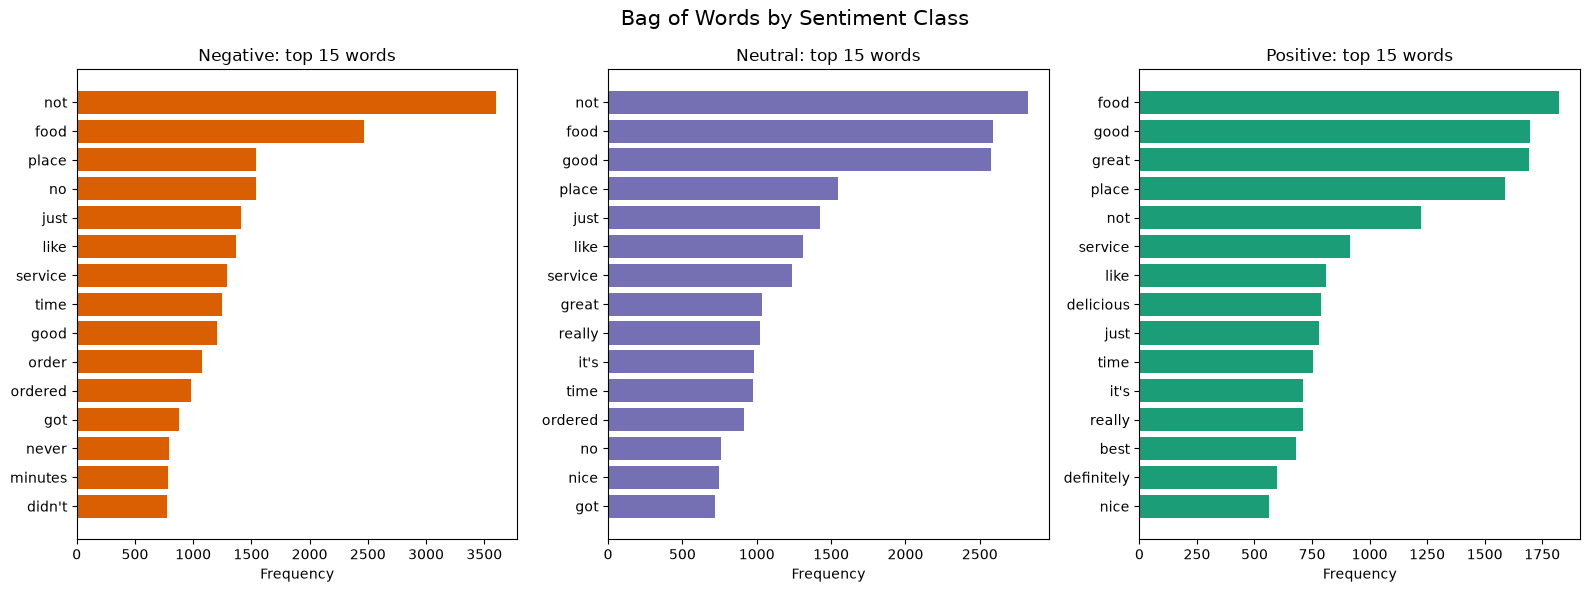

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, sentiment in zip(axes, LABELS):
    table = top_word_tables[sentiment].sort_values('count')
    ax.barh(table['word'], table['count'], color=COLORS[sentiment])
    ax.set_title(f'{sentiment}: top {TOP_WORDS} words')
    ax.set_xlabel('Frequency')

fig.suptitle('Bag of Words by Sentiment Class', fontsize=15)
fig.tight_layout()
fig.savefig(VOCAB_DIR / 'bag_of_words_by_sentiment.png', dpi=200, bbox_inches='tight')
plt.show()

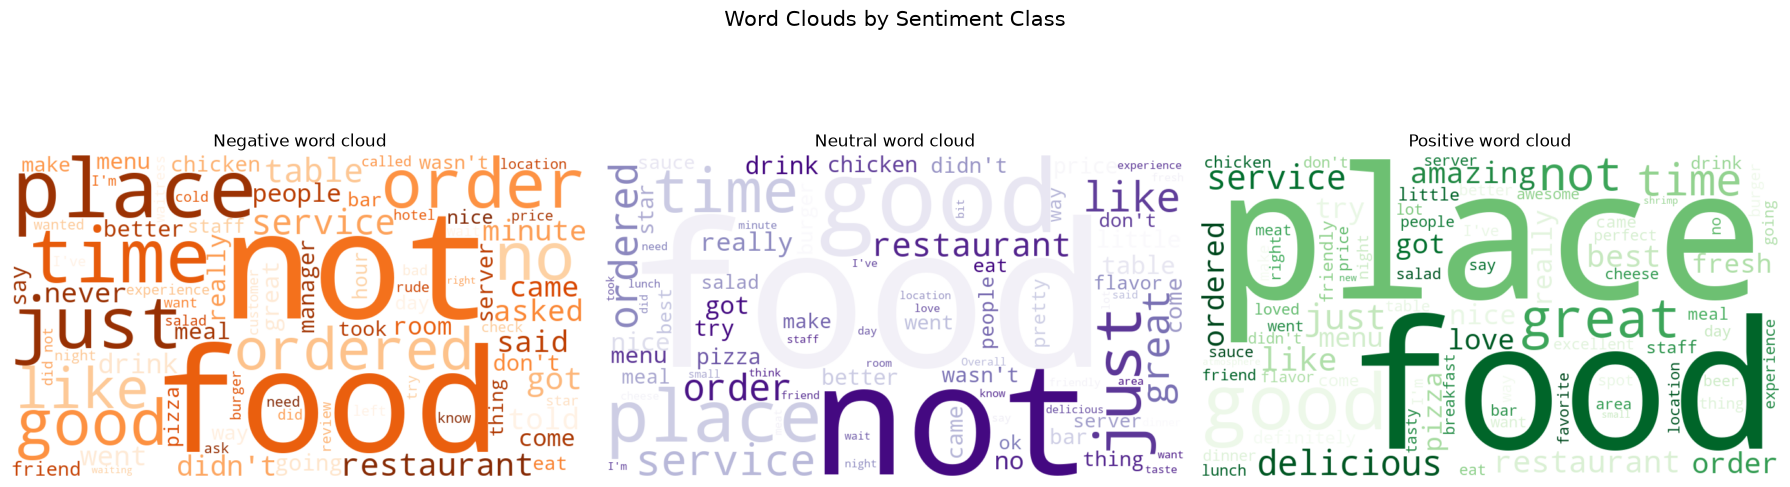

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, sentiment) in zip(axes, enumerate(LABELS)):
    text = ' '.join(vocab_sample.loc[vocab_sample['label'] == label, 'text'].fillna(''))
    cloud = WordCloud(
        width=900,
        height=500,
        background_color='white',
        stopwords=STOP_WORDS,
        colormap={'Negative': 'Oranges', 'Neutral': 'Purples', 'Positive': 'Greens'}[sentiment],
        max_words=80,
    ).generate(text)
    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(f'{sentiment} word cloud')
    ax.axis('off')

fig.suptitle('Word Clouds by Sentiment Class', fontsize=15)
fig.tight_layout()
fig.savefig(VOCAB_DIR / 'word_clouds_by_sentiment.png', dpi=200, bbox_inches='tight')
plt.show()

## LIME Interpretability

The next cell explains three correct predictions and one incorrect prediction. It does not train the model again.

Example 1: true=Negative, predicted=Negative
[(np.str_('Disgusting'), 0.20750847962725785), (np.str_('not'), 0.14461536918309598), (np.str_('no'), 0.06269287945452594), (np.str_('disappointed'), 0.0608023965370538), (np.str_('was'), -0.04670777577308509), (np.str_('very'), 0.030688686107944306), (np.str_('food'), 0.027815846510258993), (np.str_('have'), 0.0264970222204375), (np.str_('love'), -0.018139571970781157), (np.str_('put'), 0.016623891178773845)]


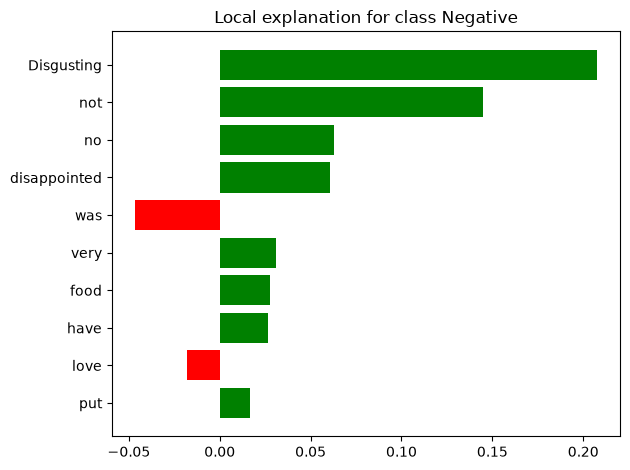

Example 2: true=Neutral, predicted=Neutral
[(np.str_('decent'), 0.08733966342537464), (np.str_('okay'), 0.060780098832883475), (np.str_('probably'), 0.04497554705322421), (np.str_('but'), 0.044204271924840825), (np.str_('again'), 0.03980452300570675), (np.str_('was'), 0.035377460944989385), (np.str_('happy'), 0.03516223381693432), (np.str_('will'), 0.03379842549393342), (np.str_('minutes'), -0.02230883410994628), (np.str_('least'), -0.02175193658831329)]


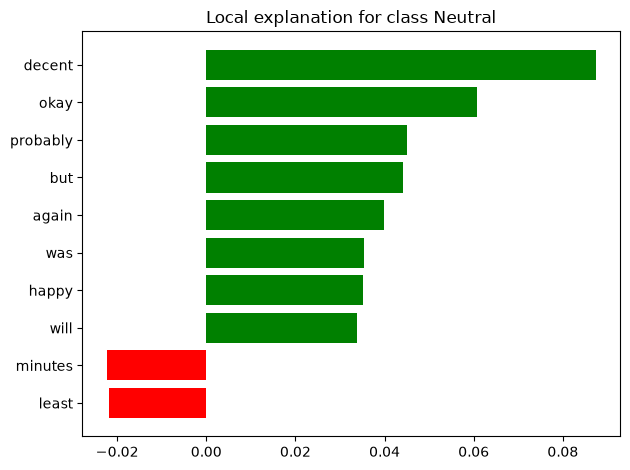

Example 3: true=Positive, predicted=Positive
[(np.str_('Very'), 0.15175704094858342), (np.str_('Worth'), 0.08736075093305594), (np.str_('wings'), 0.06010418415035134), (np.str_('topped'), 0.045986016409038), (np.str_('digs'), 0.04513795520581306), (np.str_('over'), 0.037478881906039124), (np.str_('pizza'), 0.026175279714976216), (np.str_('and'), 0.025984108454467893), (np.str_('hand'), 0.023203655498810805), (np.str_('cozy'), -0.019838512943503014)]


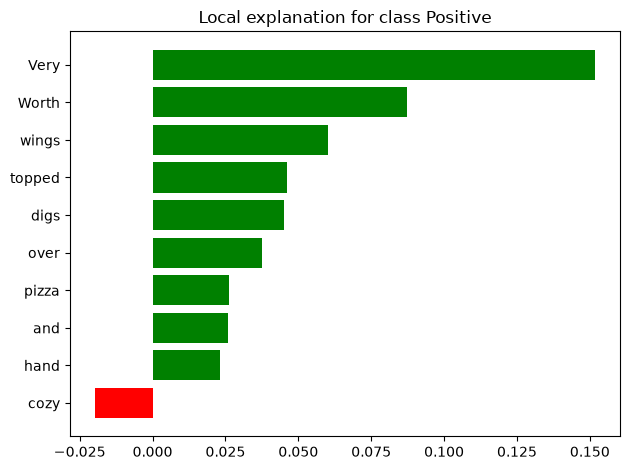

Example 4: true=Negative, predicted=Neutral
[(np.str_('worse'), -0.22790788681372215), (np.str_('expecting'), 0.11818048881412621), (np.str_('was'), 0.10334565873206163), (np.str_('bit'), 0.08392891385155613), (np.str_('Needless'), -0.08252390626294376), (np.str_('before'), -0.06910104369762106), (np.str_('boiled'), -0.0604169529747173), (np.str_('pleasantly'), 0.05398571087852214), (np.str_('at'), -0.05094579866759918), (np.str_('far'), -0.046656398497109244)]


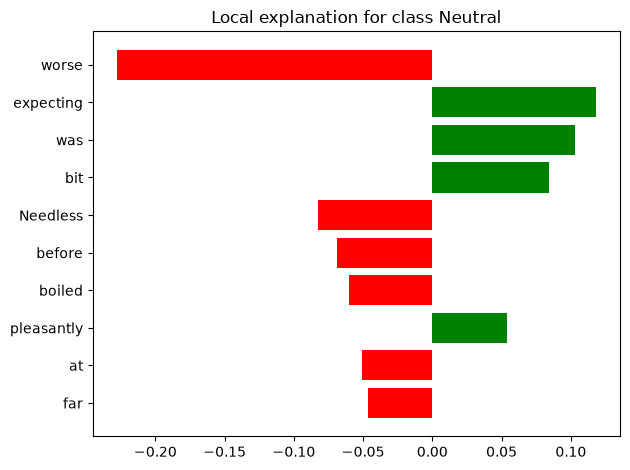

In [12]:
# Run once if needed: !pip install -q lime
NUM_SAMPLES = 1000
NUM_FEATURES = 10
LIME_DIR = FINAL_DIR / 'lime'
LIME_DIR.mkdir(parents=True, exist_ok=True)

lime_model = final_model.to(DEVICE)
lime_model.eval()

def predict_proba(texts):
    batches = []
    for start in range(0, len(texts), 64):
        encoded = tokenizer(
            list(texts[start:start + 64]),
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors='pt',
        )
        encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
        with torch.no_grad():
            batches.append(torch.softmax(lime_model(**encoded).logits, dim=1).cpu().numpy())
    return np.vstack(batches)

examples = []
for label in LABELS:
    examples.append(
        results_df[(results_df['true_sentiment'] == label) & (results_df['is_correct'])]
        .sample(1, random_state=RANDOM_STATE)
    )

errors = results_df[~results_df['is_correct']]
if not errors.empty:
    examples.append(errors.sample(1, random_state=RANDOM_STATE))

examples = pd.concat(examples, ignore_index=True)
explainer = LimeTextExplainer(class_names=LABELS, random_state=RANDOM_STATE)
summary = []

for i, row in examples.iterrows():
    probabilities = predict_proba([row['text']])[0]
    predicted_label = int(np.argmax(probabilities))
    explanation = explainer.explain_instance(
        row['text'], predict_proba, labels=[predicted_label],
        num_features=NUM_FEATURES, num_samples=NUM_SAMPLES,
    )

    words = explanation.as_list(label=predicted_label)
    print(f"Example {i + 1}: true={row['true_sentiment']}, predicted={LABELS[predicted_label]}")
    print(words)

    figure = explanation.as_pyplot_figure(label=predicted_label)
    figure.tight_layout()
    figure.savefig(LIME_DIR / f'example_{i + 1}.png', dpi=200)
    plt.show()

    summary.append({
        'example': i + 1,
        'true_label': row['true_sentiment'],
        'predicted_label': LABELS[predicted_label],
        'correct': row['is_correct'],
        'lime_words': str(words),
    })

pd.DataFrame(summary).to_csv(LIME_DIR / 'lime_summary.csv', index=False)
